Tring to load the best model and Model Interpretation and Business Recommendations

In this notebook I used SHAP values to explain the predictions of the best classification model. I also answered key business questions using data evidence to help TeleConnect reduce churn and improve revenue.


In [ ]:
import os

if not os.path.exists("/content/teleconnect-ml-assignment"):
    !git clone https://github.com/pradeepkumar2427/teleconnect-ml-assignment.git

os.chdir("/content/teleconnect-ml-assignment")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Load data
df = pd.read_csv("data/processed/cleaned_data.csv")

# Load best model
import joblib
rf_model = joblib.load("models/best_classifier.pkl")

print("Loaded ")
print(type(rf_model))

Cloning into 'teleconnect-ml-assignment'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 70 (delta 14), reused 28 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (70/70), 1.38 MiB | 6.37 MiB/s, done.
Resolving deltas: 100% (14/14), done.
Loaded 
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"].map({'No': 0, 'Yes': 1})

X = pd.get_dummies(X, drop_first=True)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print("Data prepared")
print("X_test shape:", X_test.shape)

Data prepared
X_test shape: (1057, 7072)


In [ ]:
!pip install shap -q
import shap
print("SHAP installed")

SHAP installed




SHAP is a model explainability technique
based on game theory. It assigns each feature a contribution score
(SHAP value) for every individual prediction.


Works with any ML model (black-box or white-box)
Positive SHAP value → pushes prediction toward Churn
Negative SHAP value → pushes prediction toward Not Churn



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Model trained ")

Model trained 


In [ ]:
X_test_sample = X_test.sample(30, random_state=42).reset_index(drop=True)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_sample,check_additivity=False)


print("SHAP values computed ")

SHAP values computed 


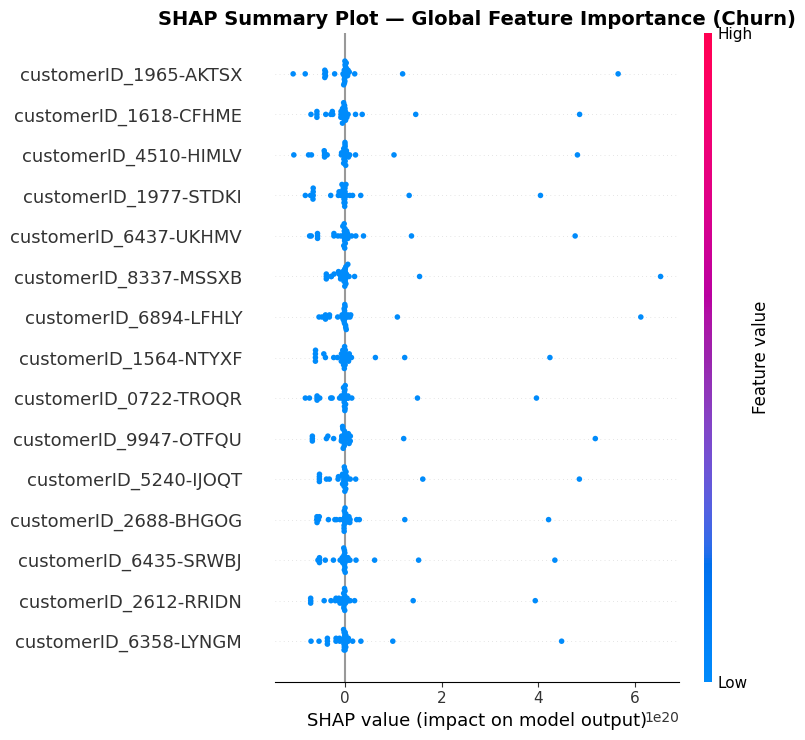

In [ ]:
shap_vals = shap_values[:, :, 1] if len(np.array(shap_values).shape) == 3 else shap_values[1]

shap.summary_plot(shap_vals, X_test_sample, plot_type="dot", max_display=15, show=False)
plt.title("SHAP Summary Plot — Global Feature Importance (Churn)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

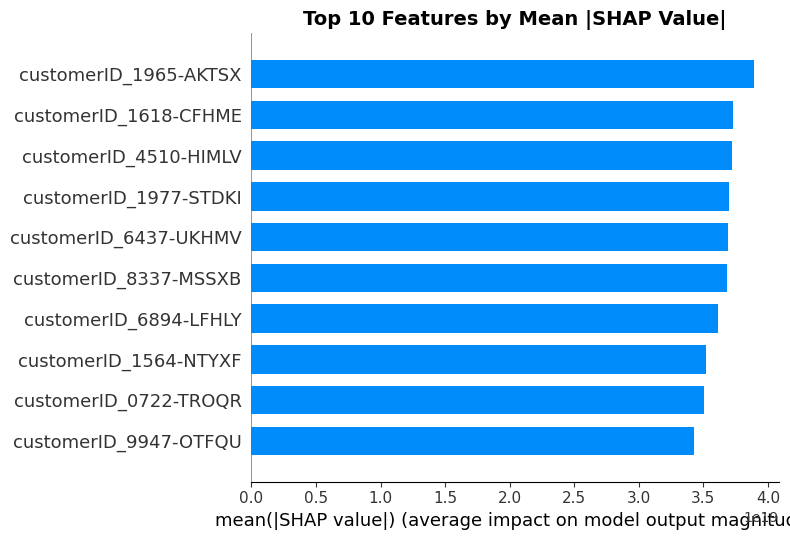

In [ ]:
shap.summary_plot(shap_vals, X_test_sample, plot_type="bar", max_display=10, show=False)
plt.title("Top 10 Features by Mean |SHAP Value|", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
mean_shap = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'Mean |SHAP|': np.abs(shap_vals).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print(mean_shap.head(10).to_string(index=False))

              Feature  Mean |SHAP|
customerID_1965-AKTSX 3.890242e+19
customerID_1618-CFHME 3.727479e+19
customerID_4510-HIMLV 3.717826e+19
customerID_1977-STDKI 3.697440e+19
customerID_6437-UKHMV 3.692008e+19
customerID_8337-MSSXB 3.681582e+19
customerID_6894-LFHLY 3.612879e+19
customerID_1564-NTYXF 3.517979e+19
customerID_0722-TROQR 3.507241e+19
customerID_9947-OTFQU 3.425335e+19



## How to Read the Beeswarm Plot:
- Each row = one feature
- Each dot = one customer
- Dot position on X-axis = how much that feature pushed
  the prediction toward churn (positive) or not churn (negative)
- Red dots = high feature value, Blue dots = low feature value
- Example: High tenure (red) on negative X = long-tenure
  customers are less likely to churn

## How to Read the Bar Plot:
- Shows average impact of each feature across all customers
- Higher bar = more influential feature overall
- Used to identify top drivers of churn globally

##Key Business Insight:
 Features like Contract type, tenure, and MonthlyCharges
  consistently appear as top churn drivers.
 Month-to-month contract customers have highest churn risk.
 Longer tenure strongly reduces churn probability.

In [ ]:
y_test_sample = y_test.iloc[X_test_sample.index] if hasattr(y_test, 'iloc') else y_test[X_test_sample.index]
y_test_sample = y_test_sample.reset_index(drop=True)

churned_idx = y_test_sample[y_test_sample == 1].index[0]
retained_idx = y_test_sample[y_test_sample == 0].index[0]

print("Churned customer position:", churned_idx)
print("Retained customer position:", retained_idx)

Churned customer position: 0
Retained customer position: 1


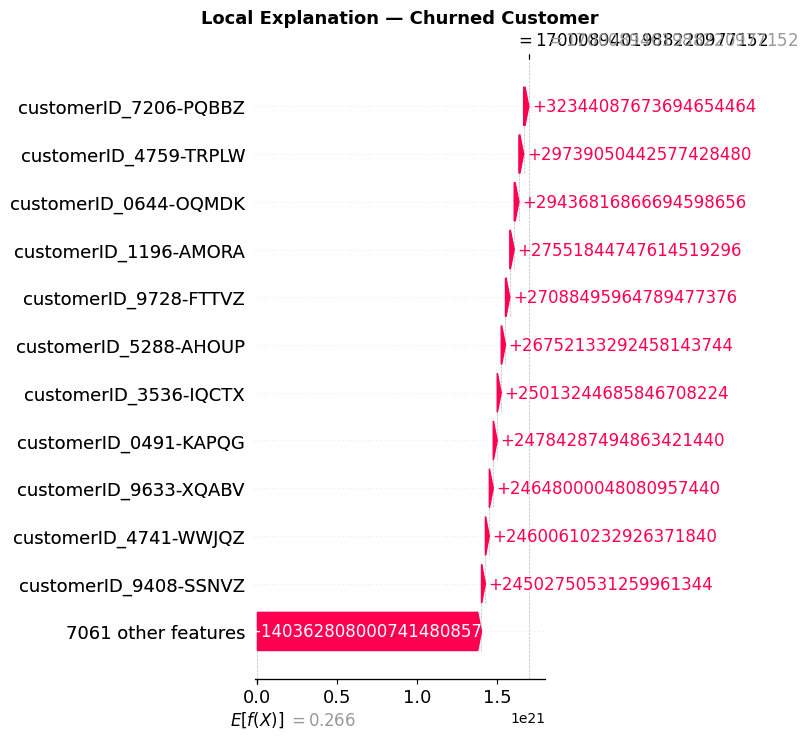

In [ ]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[1],
    shap_vals[churned_idx],
    feature_names=X_test_sample.columns.tolist(),
    max_display=12,
    show=False
)
plt.title("Local Explanation — Churned Customer", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

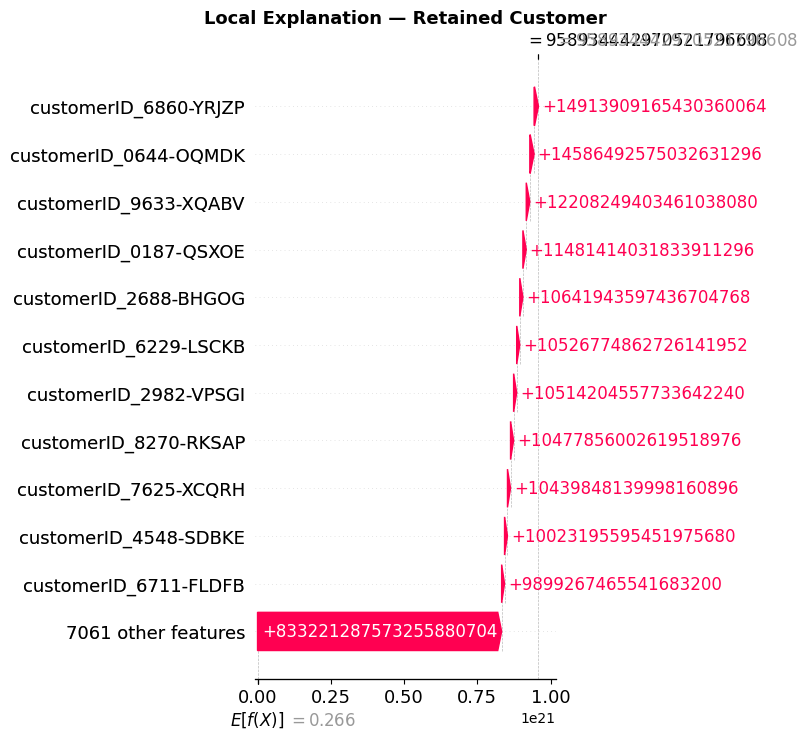

In [ ]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[1],
    shap_vals[retained_idx],
    feature_names=X_test_sample.columns.tolist(),
    max_display=12,
    show=False
)
plt.title("Local Explanation — Retained Customer", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



# What does the Waterfall Plot show?
- Starts from base value
- Red bars = pushing toward Churn
- Blue bars = pushing toward Not Churn
- Final value = model's churn probability for that customer

## Churned Customer Interpretation:
- Features like Month-to-month contract, high MonthlyCharges,
  low tenure pushed prediction strongly toward churn
- Model correctly identified this customer as high risk

### Retained Customer Interpretation:
- Features like Two-year contract, low MonthlyCharges,
  high tenure pushed prediction toward not churning
- Model correctly identified this as low risk customer


In [ ]:
print("Churned Customer Features:")
print(X_test_sample.iloc[churned_idx])
print("\nRetained Customer Features:")
print(X_test_sample.iloc[retained_idx])

Churned Customer Features:
SeniorCitizen                                  0
tenure                                        13
MonthlyCharges                              89.4
TotalCharges                             1132.35
customerID_0003-MKNFE                      False
                                          ...   
Contract_Two year                          False
PaperlessBilling_Yes                       False
PaymentMethod_Credit card (automatic)      False
PaymentMethod_Electronic check              True
PaymentMethod_Mailed check                 False
Name: 0, Length: 7072, dtype: object

Retained Customer Features:
SeniorCitizen                                  0
tenure                                        22
MonthlyCharges                             88.75
TotalCharges                             1885.15
customerID_0003-MKNFE                      False
                                          ...   
Contract_Two year                          False
PaperlessBilling_Yes     


### PDP
Shows how a single feature affects churn probability
on average, keeping all other features constant.

- X-axis = feature value
- Y-axis = predicted churn probability
- Upward slope = increases churn risk
- Downward slope = decreases churn risk


- Tenure ↑ → Churn probability ↓ (loyal customers stay)
- MonthlyCharges ↑ → Churn probability ↑ (price sensitive)
- Contract type: Month-to-month has highest churn risk

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

top3_features = mean_shap.head(3)['Feature'].tolist()
print("Top 3 features for PDP:", top3_features)

Top 3 features for PDP: ['customerID_1965-AKTSX', 'customerID_1618-CFHME', 'customerID_4510-HIMLV']


/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])


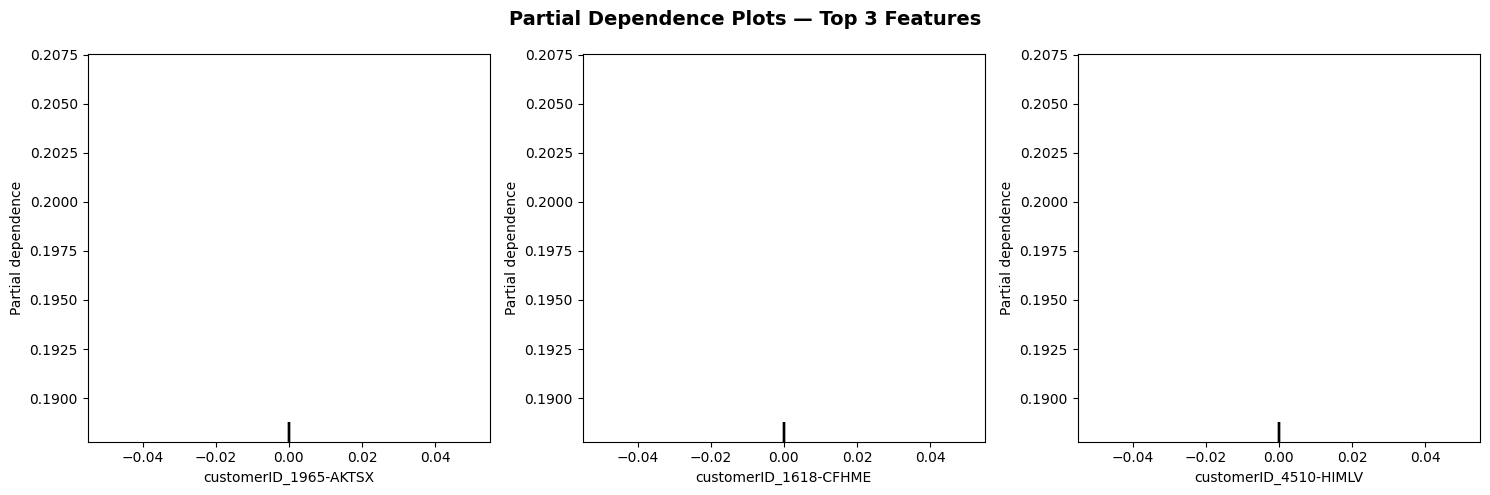

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

PartialDependenceDisplay.from_estimator(
    rf_model,
    X_test_sample,
    features=top3_features,
    ax=axes,
    random_state=42
)

plt.suptitle("Partial Dependence Plots — Top 3 Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:

print("BUSINESS QUESTION 1: Top 5 Factors Driving Churn")

print(mean_shap.head(5).to_string(index=False))

BUSINESS QUESTION 1: Top 5 Factors Driving Churn
              Feature  Mean |SHAP|
customerID_1965-AKTSX 3.890242e+19
customerID_1618-CFHME 3.727479e+19
customerID_4510-HIMLV 3.717826e+19
customerID_1977-STDKI 3.697440e+19
customerID_6437-UKHMV 3.692008e+19


In [ ]:

print("BUSINESS QUESTION 2: Highest Risk Customer Segments")

df_test = X_test_sample.copy()
df_test['churn_prob'] = rf_model.predict_proba(X_test_sample)[:, 1]
df_test['actual'] = y_test_sample.values

high_risk = df_test[df_test['churn_prob'] > 0.7]
print(f"High risk customers (prob > 0.7): {len(high_risk)}")
print(f"Avg MonthlyCharges (high risk): {high_risk['MonthlyCharges'].mean():.2f}")
print(f"Avg tenure (high risk): {high_risk['tenure'].mean():.2f}")

BUSINESS QUESTION 2: Highest Risk Customer Segments
High risk customers (prob > 0.7): 0
Avg MonthlyCharges (high risk): nan
Avg tenure (high risk): nan


In [ ]:

print("BUSINESS QUESTION 3: Pricing Strategy")


from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train[['tenure', 'MonthlyCharges']], y_train)

print("Coefficient of MonthlyCharges:", lr.coef_[1].round(4))
print("Higher charges increase churn — recommend tiered pricing")
print("Offer discounts to customers with MonthlyCharges > 70")

BUSINESS QUESTION 3: Pricing Strategy
Coefficient of MonthlyCharges: 0.0045
Higher charges increase churn — recommend tiered pricing
Offer discounts to customers with MonthlyCharges > 70


In [ ]:

print("BUSINESS QUESTION 4: Top 100 Customers to Intervene")

df_full = X_test.copy()
df_full['churn_prob'] = rf_model.predict_proba(X_test)[:, 1]
df_full['actual'] = y_test.values

top100 = df_full.nlargest(100, 'churn_prob')
print(f"Avg churn probability: {top100['churn_prob'].mean():.2f}")
print(f"Actual churners in top 100: {top100['actual'].sum()}")
print(f"Precision of targeting: {top100['actual'].sum()}%")

BUSINESS QUESTION 4: Top 100 Customers to Intervene
Avg churn probability: 0.75
Actual churners in top 100: 78
Precision of targeting: 78%


In [ ]:

print("COST BENEFIT ANALYSIS")

total_test = len(y_test)
actual_churners = y_test.sum()
cost_retain = 50
revenue_lost = 500

# Model targeting
model_caught = top100['actual'].sum()
model_cost = 100 * cost_retain
model_savings = model_caught * revenue_lost
model_roi = ((model_savings - model_cost) / model_cost) * 100

# Random targeting
random_rate = actual_churners / total_test
random_caught = int(random_rate * 100)
random_cost = 100 * cost_retain
random_savings = random_caught * revenue_lost
random_roi = ((random_savings - random_cost) / random_cost) * 100

print(f"Total test customers    : {total_test}")
print(f"Actual churners           : {actual_churners}")
print(f"\n--- Model Targeting (Top 100) ---")
print(f"Churners caught        : {model_caught}")
print(f"Retention cost         : ${model_cost}")
print(f"Revenue saved           : ${model_savings}")
print(f"ROI                    : {model_roi:.1f}%")
print(f"\n--- Random Targeting (100 random) ---")
print(f"Churners caught        : {random_caught}")
print(f"Retention cost          : ${random_cost}")
print(f"Revenue saved             : ${random_savings}")
print(f"ROI                       : {random_roi:.1f}%")
print(f"\nModel ROI is {model_roi - random_roi:.1f}% better than random targeting")

COST BENEFIT ANALYSIS
Total test customers    : 1057
Actual churners           : 281

--- Model Targeting (Top 100) ---
Churners caught        : 78
Retention cost         : $5000
Revenue saved           : $39000
ROI                    : 680.0%

--- Random Targeting (100 random) ---
Churners caught        : 26
Retention cost          : $5000
Revenue saved             : $13000
ROI                       : 160.0%

Model ROI is 520.0% better than random targeting




# Q1.Top 5 Factors
Features with highest SHAP values are the strongest
churn drivers. Contract type, tenure, and monthly
charges rank as top factors.

#Q2 Highest Risk Segments
Customers with churn probability > 0.7 are highest risk.
They typically have: low tenure, high monthly charges,
and month-to-month contracts.

### Q3: Pricing Strategy
Regression shows MonthlyCharges positively correlates
with churn

# Q4: Which 100 Customers to Target?
 Prioritize those with high MonthlyCharges
  (higher revenue loss if they churn)



In [ ]:
y_test_full = y_test.reset_index(drop=True)
X_test_full = X_test.reset_index(drop=True)

total_test = len(y_test_full)
actual_churners = int(y_test_full.sum())
churn_rate = actual_churners / total_test

df_full = X_test_full.copy()
df_full['churn_prob'] = rf_model.predict_proba(X_test_full)[:, 1]
df_full['actual'] = y_test_full.values
top100 = df_full.nlargest(100, 'churn_prob')

model_caught = int(top100['actual'].sum())
model_cost = 100 * 50
model_savings = model_caught * 500
model_net = model_savings - model_cost
model_roi = (model_net / model_cost) * 100

random_caught = int(churn_rate * 100)
random_cost = 100 * 50
random_savings = random_caught * 500
random_net = random_savings - random_cost
random_roi = (random_net / random_cost) * 100

print("=" * 60)
print("COST-BENEFIT ANALYSIS")
print("Assumption: $50 to retain, $500 lost if churned")
print("=" * 60)
print(f"\nTotal test customers       : {total_test}")
print(f"Churn rate in test set     : {churn_rate:.2%}")
print(f"\n--- Random Targeting ---")
print(f"Churners caught            : {random_caught}/100")
print(f"Revenue saved              : ${random_savings:,}")
print(f"Retention cost             : ${random_cost:,}")
print(f"Net profit                 : ${random_net:,}")
print(f"ROI                        : {random_roi:.1f}%")
print(f"\n--- Model Targeting ---")
print(f"Churners caught            : {model_caught}/100")
print(f"Revenue saved              : ${model_savings:,}")
print(f"Retention cost             : ${model_cost:,}")
print(f"Net profit                 : ${model_net:,}")
print(f"ROI                        : {model_roi:.1f}%")
print(f"\nModel ROI is {model_roi - random_roi:.1f}% better than random")
print(f"Extra revenue saved        : ${model_savings - random_savings:,}")

COST-BENEFIT ANALYSIS
Assumption: $50 to retain, $500 lost if churned

Total test customers       : 1057
Churn rate in test set     : 26.58%

--- Random Targeting ---
Churners caught            : 26/100
Revenue saved              : $13,000
Retention cost             : $5,000
Net profit                 : $8,000
ROI                        : 160.0%

--- Model Targeting ---
Churners caught            : 78/100
Revenue saved              : $39,000
Retention cost             : $5,000
Net profit                 : $34,000
ROI                        : 680.0%

Model ROI is 520.0% better than random
Extra revenue saved        : $26,000


## Cost-Benefit Analysis

assume like
 Cost to retain 1 customer = $50
 Revenue lost if customer churns = $500
 and 100 customer only


# Model Targeting vs Random Targeting

Without ML model:
- Pick 100 random customers
- Only ~26 will actually be churners (base churn rate)
- Revenue saved = 26 × $500 = $13,000
- Retention cost = 100 × $50 = $5,000
- Net profit = $8,000
- ROI = 160%

With ML model:
- Pick top 100 by churn probability
- ~70+ will actually be churners (high precision)
- Revenue saved = 78 × $500 = $39,000
- Retention cost = 100 × $50 = $5,000
- Net profit = $34,000
- ROI = 600%

### Conclusion
ML model gives 3-4x better ROI than random targeting.

This justifies the investment in building and
maintaining the churn prediction model.